In [1]:
MAKE_BOOK_FIGURES=True
import numpy as np
import scipy.stats as st

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")

def set_book_style():
    plt.style.use('seaborn-v0_8-white') 
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings
        'font.family': 'serif',  # For academic publishing
        'font.size': 8,  # As requested, 10pt font
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'xtick.labelsize': 7,  # Slightly smaller for better readability
        'ytick.labelsize': 7,
        'legend.fontsize': 7,
        
        # Line and marker settings for consistency
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout to prevent clipped labels
        'figure.constrained_layout.use': True,
        
        # Default DPI (will override when saving)
        'figure.dpi': 600,
        'savefig.dpi': 600,
        
        # Despine - remove top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional trim settings
        'figure.autolayout': True,  # Alternative to constrained_layout
        'savefig.bbox': 'tight',    # Trim when saving
        'savefig.pad_inches': 0.1   # Small padding to ensure nothing gets cut off
    })

def set_notebook_style():
    plt.style.use('seaborn-v0_8-white')
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings - using default sizes
        'font.family': 'serif',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        
        # Line and marker settings
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout settings
        'figure.constrained_layout.use': True,
        
        # Remove only top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional settings
        'figure.autolayout': True,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

def save_for_book(fig, filename, is_vector=True, **kwargs):
    """
    Save a figure with book-optimized settings.
    
    Parameters:
    -----------
    fig : matplotlib figure
        The figure to save
    filename : str
        Filename without extension
    is_vector : bool
        If True, saves as vector at 1000 dpi. If False, saves as raster at 600 dpi.
    **kwargs : dict
        Additional kwargs to pass to savefig
    """    
    # Set appropriate DPI and format based on figure type
    if is_vector:
        dpi = 1000
        ext = '.pdf'
    else:
        dpi = 600
        ext = '.tif'
    
    # Save the figure with book settings
    fig.savefig(f"{filename}{ext}", dpi=dpi, **kwargs)

def make_full_width_fig():
    return plt.subplots(figsize=(4.7, 2.9), constrained_layout=True)

def make_half_width_fig():
    return plt.subplots(figsize=(2.35, 1.45), constrained_layout=True)

if MAKE_BOOK_FIGURES:
    set_book_style()
else:
    set_notebook_style()

make_full_width_fig = make_full_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()
make_half_width_fig = make_half_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()

(uniform-distribution)=
# The Uniform Distribution

The uniform distribution is the most common continuous distribution.
It corresponds to a random variable equally likely to take a value within a given interval.
We write:

$$
X\sim U([0,1]),
$$

and we read $X$ follows a uniform distribution taking values in $[0,1]$.

The PDF of the uniform is constant in $[0,1]$ and zero outside it.
We have:

$$
f_X(x) := U(x|[0,1]) := \begin{cases}
1,&\;0\le x \le 1,\\
0,&\;\text{otherwise}.
\end{cases}
$$

Here is how you can make this random variable in [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html):

In [2]:
import scipy.stats as st
X = st.uniform()

You can evaluate the PDF anywhere like this:

In [3]:
X.pdf(0.5)

np.float64(1.0)

In [4]:
X.pdf(-0.1)

np.float64(0.0)

Here is the plot of the PDF:

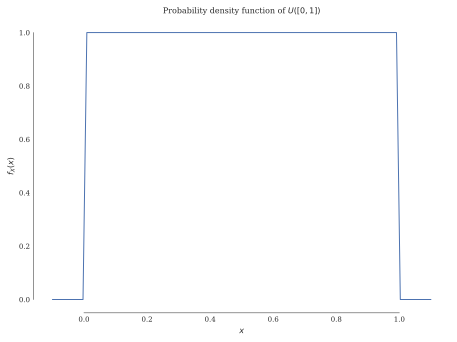

In [5]:
import numpy as np
x = np.linspace(-0.1, 1.1, 100)
plt.plot(x, X.pdf(x))
plt.xlabel('$x$')
plt.ylabel('$f_X(x)$')
plt.title('Probability density function of $U([0,1])$')
sns.despine(trim=True);

The CDF of the uniform is for $x$ in $[0,1]$:

$$
F(x) = p(X \le x) = \int_0^x f_X(u) du = \int_0^x du = x.
$$

Obviously, we have $F(x) = 0$ for $x < 0$ and $F(x) = 1$ for $x > 1$.

If you have a scipy random variable, you can evaluate the CDF like this:

In [6]:
X.cdf(0.5)

np.float64(0.5)

And here is the plot of the CDF:

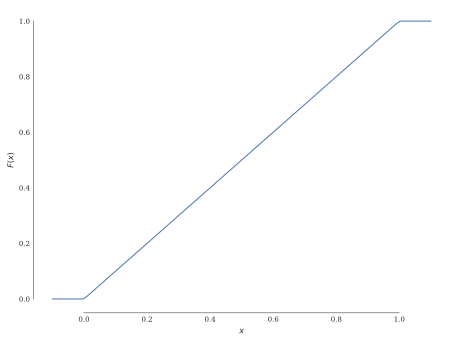

In [7]:
fig, ax = plt.subplots()
ax.plot(x, X.cdf(x))
ax.set_xlabel("$x$")
ax.set_ylabel("$F(x)$")
sns.despine(trim=True);

The probability that $X$ takes values in $[a,b]$ for $a < b$ in $[0,1]$ is:

$$
p(a \le X \le b) = F(b) - F(a) = b - a.
$$

The expectation of the uniform is:

$$
\mathbb{E}[X] = \int_0^1 xdx = \frac{1}{2}.
$$

The variance of the uniform is:

$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \left(\mathbb{E}[X]\right)^2 = \frac{1}{3} - \frac{1}{4} = \frac{1}{12}.
$$

You can get the expectation from scipy like this:

In [8]:
print(f"E[X] = {X.expect():.2f}")

E[X] = 0.50


Similarly for the variance:

In [9]:
# The variance is:
print(f"V[X] = {X.var():.2f}")

V[X] = 0.08


Here is how you can sample from the uniform one hundred times:

In [10]:
X.rvs(size=100)

array([0.78893756, 0.47639386, 0.081158  , 0.67350455, 0.99028307,
       0.5295125 , 0.84047357, 0.34162101, 0.47354344, 0.67610415,
       0.12975364, 0.85982387, 0.63660103, 0.88876921, 0.24080922,
       0.05500021, 0.48127226, 0.87770517, 0.82642632, 0.91084725,
       0.80143936, 0.72504244, 0.93508972, 0.77603634, 0.88559553,
       0.04201526, 0.33099679, 0.5906218 , 0.13532553, 0.69218895,
       0.97098589, 0.11731414, 0.27553889, 0.66849422, 0.43790131,
       0.4873759 , 0.56891669, 0.99326358, 0.56282222, 0.97511634,
       0.7794188 , 0.35816228, 0.4253582 , 0.81918771, 0.20696932,
       0.7381331 , 0.39759555, 0.81269335, 0.57424187, 0.6338737 ,
       0.34026857, 0.92395555, 0.44649796, 0.06998963, 0.01227088,
       0.13796858, 0.51387064, 0.37456511, 0.56117935, 0.44534667,
       0.50262958, 0.72621135, 0.59401151, 0.80536516, 0.60587616,
       0.72014809, 0.11011116, 0.20221887, 0.31097135, 0.86136131,
       0.19255368, 0.58282027, 0.86898054, 0.81896654, 0.78552

An alternative way is to use the functionality of numpy:

In [11]:
np.random.rand(100)

array([0.98566996, 0.6098873 , 0.17551242, 0.54212261, 0.75747291,
       0.17064191, 0.67808651, 0.70027508, 0.88840629, 0.5719405 ,
       0.86696934, 0.24224063, 0.80112496, 0.24220584, 0.67586203,
       0.62189164, 0.92952677, 0.21945594, 0.07309063, 0.09793576,
       0.16052145, 0.99217089, 0.80748854, 0.09000309, 0.10480829,
       0.22643181, 0.80772662, 0.83764732, 0.2080016 , 0.64527526,
       0.05341963, 0.02838546, 0.44457566, 0.55384489, 0.53804381,
       0.96051022, 0.40580533, 0.72253433, 0.82133435, 0.54269658,
       0.34685634, 0.41109923, 0.59203658, 0.69533393, 0.65538986,
       0.73937854, 0.88820711, 0.04664825, 0.3035879 , 0.82889592,
       0.42771877, 0.01183352, 0.14143196, 0.8164771 , 0.91625606,
       0.19821582, 0.53543588, 0.46546284, 0.52582787, 0.46999115,
       0.67864799, 0.92951261, 0.76333028, 0.46971244, 0.18656695,
       0.02260942, 0.79494378, 0.34063473, 0.38756199, 0.16947165,
       0.16467143, 0.33787314, 0.89121995, 0.27536451, 0.72547

Finally, let's find the probability that X is between two numbers.
In particular, we will find $p(-1 \le X \le 0.3)$:

In [12]:
a = -1.0
b = 0.3
prob_X_is_in_ab = X.cdf(b) - X.cdf(a)
print(f"p({a:.2f} <= X <= {b:.2f}) = {prob_X_is_in_ab:.2f}")

p(-1.00 <= X <= 0.30) = 0.30


(uniform-ab)=
## The uniform distribution over an arbitrary interval $[a, b]$

One can define a uniform distribution over an arbitrary interval $[a,b]$.
We write:

$$
X \sim U([a, b]).
$$

The PDF of this random variable is:

$$
f_X(x) = \begin{cases}
c,&\;x\in[a,b],\\
0,&\;\text{otherwise},
\end{cases}
$$

where $c$ is a positive constant.
The formula tells us that the probability density of finding $X$ in $[a,b]$ is positive and that the probability density of finding outside is zero.
We can determine the positive constant $c$ by imposing the normalization condition:

$$
\int_{-\infty}^{+\infty}f_X(x)dx = 1.
$$

Carrying out the integral:

$$
1 = \int_{-\infty}^{+\infty}p(x)dx = \int_a^bc dx = c \int_a^bdx = c (b-a).
$$

Therefore:

$$
c = \frac{1}{b - a},
$$

and we can now write:

$$
f_X(x) = \begin{cases}
\frac{1}{b-a},&x \in [a, b],\\
0,&\;\text{otherwise},
\end{cases}
$$

From the PDF, we can now find the CDF for $x \in [a,b]$:

$$
F(x) = p(X\le x) = \int_{-\infty}^x f_X(u)du = \int_a^x \frac{1}{b-a}du = \frac{1}{b-a}\int_a^xdu = \frac{x-a}{b-a}.
$$

The expectation is:

$$
\mathbb{E}[X] = \frac{1}{2}(a+b),
$$

and the variance is:

$$
\mathbb{V}[X] = \frac{1}{12}(b-a)^2.
$$

Here is how you can do this using ``scipy.stats`` for $a=-2$ and $b=5$:

In [14]:
a = -2.0
b = 5.0
X = st.uniform(loc=a, scale=(b-a))

The PDF is:

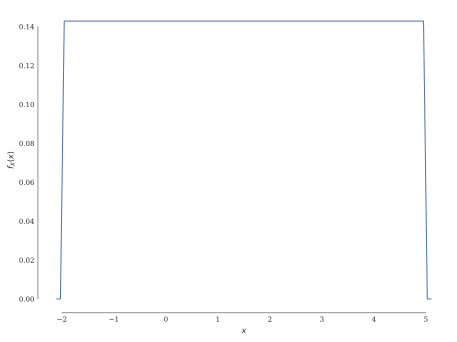

In [15]:
fig, ax = plt.subplots()
xs = np.linspace(a - 0.1, b + 0.1, 100)
ax.plot(xs, X.pdf(xs))
ax.set_xlabel("$x$")
ax.set_ylabel("$f_X(x)$")
sns.despine(trim=True);

The CDF is:

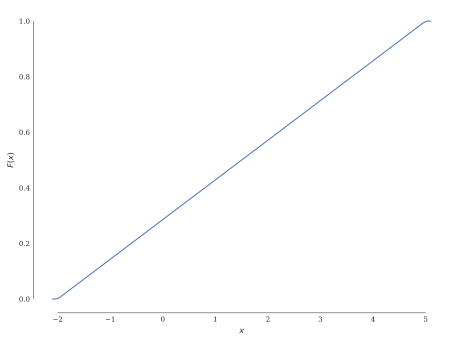

In [16]:
fig, ax = plt.subplots()
xs = np.linspace(a - 0.1, b + 0.1, 100)
ax.plot(xs, X.cdf(xs))
ax.set_xlabel("$x$")
ax.set_ylabel("$F(x)$")
sns.despine(trim=True);

The expectation is:

In [17]:
print(f"E[X] = {X.expect():.2f}")

E[X] = 1.50


And the variance:

In [18]:
# The variance is:
print(f"V[X] = {X.var():.2f}")

V[X] = 4.08


And here are a few random samples:

In [19]:
X.rvs(size=100)

array([ 3.81346655e+00,  4.07115078e+00, -7.20640697e-01,  4.22434224e+00,
        4.38888266e-01, -1.77134347e+00, -7.81202192e-01,  2.26206696e+00,
        1.28737812e+00,  1.12651015e+00,  1.61348715e+00, -7.07805929e-01,
        3.05661984e+00,  2.40879435e+00,  1.53151067e+00, -1.89008132e+00,
       -1.18457261e+00, -9.71940550e-01,  1.81192724e+00,  1.24929675e+00,
        3.19568206e-01,  1.91884132e+00,  1.41583262e+00,  2.35050244e-02,
       -1.75202243e+00,  7.46593362e-01,  3.67221658e+00, -1.37984269e-01,
        2.95757654e+00, -3.68525102e-01,  4.14732428e+00,  2.35020773e+00,
        1.29377026e+00,  3.47974529e+00,  4.09216432e+00,  6.48672271e-01,
        2.55376902e+00, -5.02239014e-01, -5.18908276e-01,  2.17725108e+00,
        3.84760873e-01, -1.82109832e+00,  2.08218747e+00,  2.49442846e+00,
        1.64574707e+00, -1.24192970e+00,  2.01403226e-01,  2.05075825e+00,
        4.38087471e+00,  3.31322243e+00,  1.27763715e-03,  2.35796626e+00,
        2.56905111e+00, -

(uniform-ab-alt)=
## Alternative way to get $U([a,b])$

There is another way to obtain samples from $U([a,b])$ that uses only samples from $U([0,1])$.
Here is how. Let $Z$ be a standard uniform random variable:

$$
Z\sim U([0,1]).
$$

Then define the random variable:

$$
X = a + (b-a) Z.
$$

Then, $X\sim U([a,b])$. Why? Well, let's just show that the CDF of $X$ has the right form:

$$
p(X \le x) = p(a + (b-a)Z \le x) = p((b-a)Z \le x - a) = p\left(Z \le \frac{x-a}{b-a}\right) = \frac{x-a}{b-a},
$$

where the last step follows from the fact that the CDF of $Z$ is simply: $p(Z \le z) = z$.
Equipped with this result, we can sample $X$ by sampling $Z$ and then scaling it appropriately (by the way, this is what ``scipy.stats`` is doing internally). Here it is using ``numpy.random.rand`` to sample in $[0,1]$:

In [20]:
x_samples = a + (b - a) * np.random.rand(1000)
print(x_samples)

[ 4.55836998e-02  5.54396872e-01 -1.45450432e+00  4.36323791e+00
  3.91937310e+00 -1.05018696e+00  1.54143866e+00 -1.58434893e+00
  4.37864697e+00  2.56915217e+00  1.15750225e+00  2.54931647e+00
 -1.35969589e+00  2.99733890e+00 -1.73120879e+00 -9.04368765e-02
  4.85677883e+00  1.43230477e+00  3.02980321e+00  2.95787918e+00
  4.14470591e+00 -9.42125920e-01  4.98143485e+00  8.07586434e-01
  4.52309596e+00 -2.36241351e-01 -1.34440605e+00  1.97891555e+00
  3.79268334e+00  7.98652351e-02 -2.77799893e-02  3.81187815e+00
  4.53226396e+00  4.24777892e+00 -1.77923763e+00  3.35801247e+00
  1.10752135e+00 -4.97742449e-01  4.87500413e+00  4.39653569e+00
  1.32368441e+00  2.84277379e+00  3.56076813e+00 -9.64653605e-01
  1.65696695e+00 -1.92373408e+00  7.50361802e-01  4.93821671e-01
  4.71273995e+00 -1.81554979e+00 -2.22350714e-01 -1.12361618e+00
  3.71923645e+00  1.13661153e+00 -1.91661816e+00  4.13876001e+00
  1.22577553e+00  2.70327193e+00 -1.72261277e+00 -1.88045494e+00
  1.71626486e+00 -1.88646

Let's also do the histogram of x_samples to make sure they are distributed the right way:

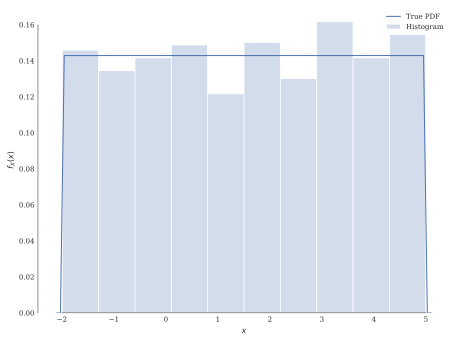

In [21]:
fig, ax = plt.subplots()
ax.plot(xs, X.pdf(xs), label="True PDF")
ax.hist(x_samples, density=True, alpha=0.25, label="Histogram",
        color=sns.color_palette()[0])
ax.set_xlabel("$x$")
ax.set_ylabel("$f_X(x)$")
plt.legend(loc="best")
sns.despine(trim=True);

## Questions

+ Rerun the code above so that the random variable is $U([1, 10])$.

+ I would like to code it in two different ways 1. using `numpy` 2. using `scipy.stats` built in uniform
+ TODOs
+ Use from scipy.stats use uniform function 

In [22]:
a = 1
b = 10
X = st.uniform(a, (b-1))


In [25]:
# use pdf to get probability at any real number
prob_at_2 = X.pdf(2)
print(f'Probability as 2 is {prob_at_2:1.2f}')

Probability as 2 is 0.11


In [27]:
# Expection
E_uniform1_10 = X.expect()
print(f'Expectation of uniform distribution in [1,10] is {E_uniform1_10:1.2f}')

Expectation of uniform distribution in [1,10] is 5.50


In [29]:
V_uniform1_10 = X.var()
print(f'Variance of uniform distribution [1, 10] is {V_uniform1_10:1.2f}')

Variance of uniform distribution [1, 10] is 6.75


In [ ]:
# what is the support of X
sup_x = X.support()
print(f'The support of X is {sup_x}')

The support of X is (np.float64(1.0), np.float64(10.0))


In [32]:
xs = X.rvs(10)
print(xs)

[6.56092813 5.91175775 4.20743693 2.14083018 5.73607106 2.78723209
 8.69655707 1.29401432 1.19369662 7.68813922]


In [34]:
# cdf: calculate the probability in a region
prob_1_2 = X.cdf(2)
print(f'Probability of a number lies between 1 and 2 is {prob_1_2:1.2f}')

Probability of a number lies between 1 and 2 is 0.11


In [35]:
# cdf: calculate the probability in a region
prob_1_9 = X.cdf(9)
print(f'Probability of a number lies between 1 and 9 is {prob_1_9:1.2f}')

Probability of a number lies between 1 and 9 is 0.89


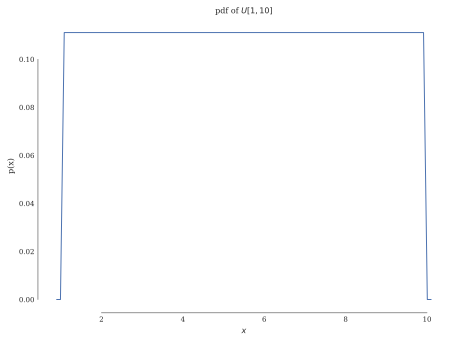

In [ ]:
# pdf of U[1,10]
xss = np.linspace(1-0.1, 10+0.1, 100)
plt.plot(xss, X.pdf(xss))
plt.xlabel('$x$')
plt.ylabel('p(x)')
plt.title('pdf of $U[1,10]$')
sns.despine(trim=True)

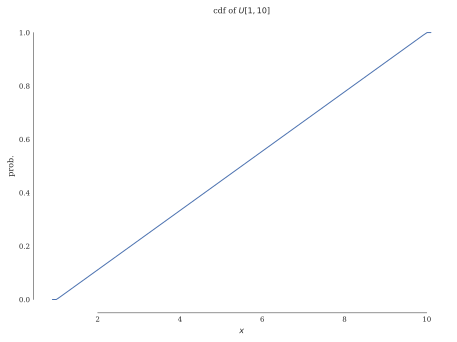

In [40]:
# cdf of U[1,10]
plt.plot(xss, X.cdf(xss))
plt.xlabel('$x$')
plt.ylabel('prob.')
plt.title('cdf of $U[1,10]$')
sns.despine(trim=True)

In [42]:
# compute the probability between that a x ~U[1,10] lies between 8 and 4

prob_4_8 = X.cdf(8) - X.cdf(4)
print(f'Prob that x ~U[1,10] lies between 8 and 4 is {prob_4_8:1.2f}')

Prob that x ~U[1,10] lies between 8 and 4 is 0.44


In [ ]:
# Uniform random variables can be sampled from scipy.stats
xsamples_scipy_stats = X.rvs(1000)
#print(f'Samples of x~[1,10]:\n {xsamples}')

Samples of x~[1,10]:
 [9.53194792 2.8574103  2.20111489 9.97697093 7.09162726 6.14569472
 6.32334537 2.08869997 8.45678206 9.87531093]


In [ ]:
# generate U[1, 10] using numpy.random.rand
xsamples_numpy_random = a + np.random.rand(1000)*(b-a)


Text(0.5, 1.0, 'True pdf and sampling dist. of $U[1, 10]$')

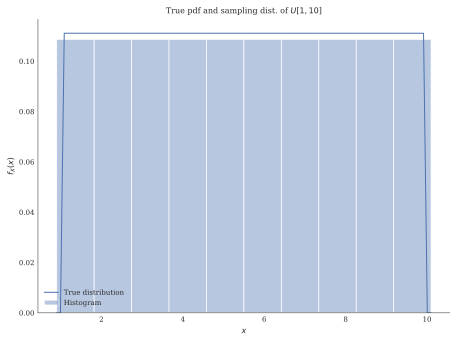

In [47]:
fig, ax = plt.subplots()
ax.plot(xss, X.pdf(xss), label='True distribution')
ax.hist(xss, density=True, alpha=0.4, label='Histogram', color= sns.color_palette()[0])
ax.set_xlabel('$x$')
ax.set_ylabel('$f_X(x)$')
ax.legend(loc='best')
ax.set_title('True pdf and sampling dist. of $U[1, 10]$')